In [2]:
import zipfile

zip_path = "/content/Project10_Quality Prediction in a Mining Process.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/Project10")

print("Extracted Successfully!")

Extracted Successfully!


In [3]:
import os

for root, dirs, files in os.walk("/content/Project10"):
    for file in files:
        print(os.path.join(root, file))

/content/Project10/Project10/Project10_Quality Prediction in a Mining Process.docx
/content/Project10/Project10/Project10_Quality Prediction in a Mining Process.zip


In [4]:
import zipfile

zip_path = "/content/Project10/Project10/Project10_Quality Prediction in a Mining Process.zip"
extract_path = "/content/Project10/Dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Inner ZIP Extracted Successfully!")

✅ Inner ZIP Extracted Successfully!


In [5]:
import os

for root, dirs, files in os.walk("/content/Project10/Dataset"):
    for file in files:
        print(os.path.join(root, file))

/content/Project10/Dataset/MiningProcess_Flotation_Plant_Database.csv


In [6]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

os.makedirs("graphs", exist_ok=True)

df = pd.read_csv("/content/Project10/Dataset/MiningProcess_Flotation_Plant_Database.csv")

print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)

✅ Dataset Loaded Successfully!
Shape: (737453, 24)


In [7]:
print(df.head())

                  date % Iron Feed % Silica Feed Starch Flow Amina Flow  \
0  2017-03-10 01:00:00        55,2         16,98     3019,53    557,434   
1  2017-03-10 01:00:00        55,2         16,98     3024,41    563,965   
2  2017-03-10 01:00:00        55,2         16,98     3043,46    568,054   
3  2017-03-10 01:00:00        55,2         16,98     3047,36    568,665   
4  2017-03-10 01:00:00        55,2         16,98     3033,69    558,167   

  Ore Pulp Flow Ore Pulp pH Ore Pulp Density Flotation Column 01 Air Flow  \
0       395,713     10,0664             1,74                      249,214   
1       397,383     10,0672             1,74                      249,719   
2       399,668      10,068             1,74                      249,741   
3       397,939     10,0689             1,74                      249,917   
4       400,254     10,0697             1,74                      250,203   

  Flotation Column 02 Air Flow  ... Flotation Column 07 Air Flow  \
0                 

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

In [9]:
print(df.isnull().sum())

date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64


In [10]:
print(df.describe(include='all'))

                       date % Iron Feed % Silica Feed Starch Flow Amina Flow  \
count                737453      737453        737453      737453     737453   
unique                 4097         278           293      409317     319416   
top     2017-09-09 23:00:00       64,03          6,26      2562,5    534,668   
freq                    180      142560        142560         690        959   

       Ore Pulp Flow Ore Pulp pH Ore Pulp Density  \
count         737453      737453           737453   
unique        180189      131143           105805   
top          402,246     10,0591             1,75   
freq            1735        1509             3214   

       Flotation Column 01 Air Flow Flotation Column 02 Air Flow  ...  \
count                        737453                       737453  ...   
unique                        43675                        80442  ...   
top                         299,927                      255,322  ...   
freq                          13683      

In [11]:
df.shape

(737453, 24)

In [12]:
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.replace(",", ".", regex=False)

for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

print("\nData Types After Conversion:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

Columns:
Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Data Types After Conversion:

date                            datetime64[ns]
% Iron Feed                            float64
% Silica Feed                          float64
Starch Flow                            float64
Amina Flow                             float64
Ore Pulp Flow                         

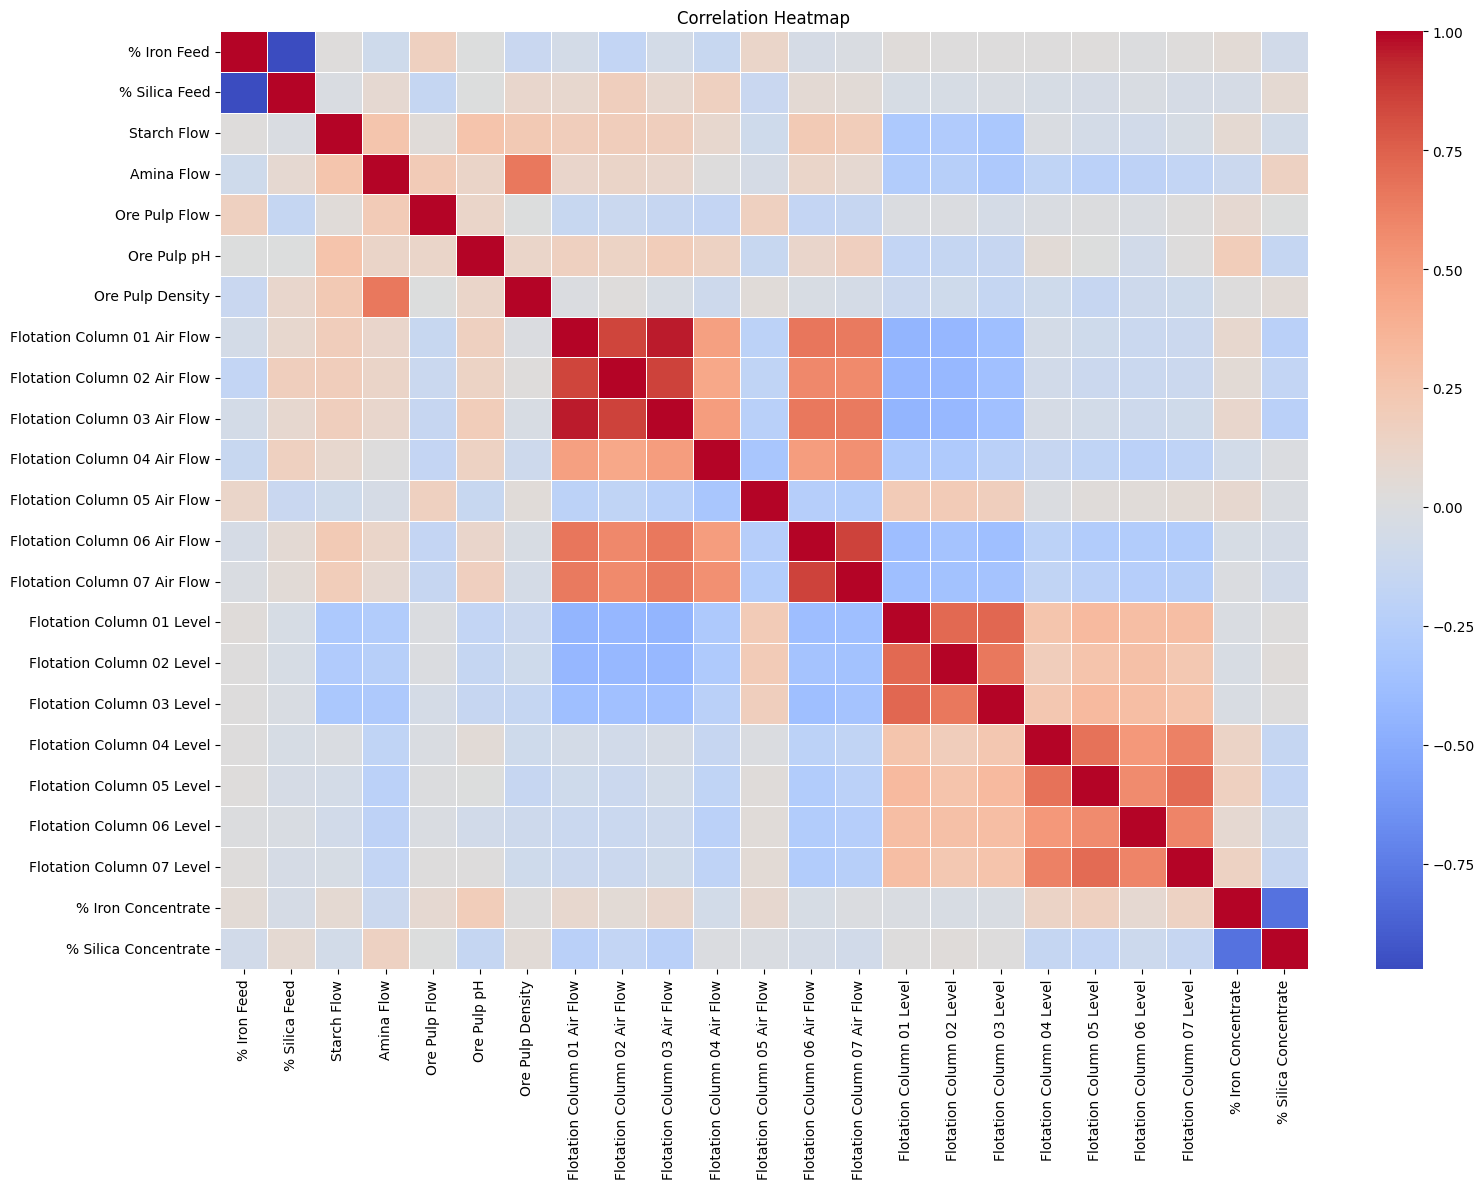

In [13]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("graphs/correlation_heatmap.png", dpi=300)
plt.show()

In [14]:
X = df.drop(columns=["% Silica Concentrate"])

y = df["% Silica Concentrate"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Features Shape : (737453, 23)
Target Shape : (737453,)

Training Data : (589962, 23)
Testing Data : (147491, 23)


In [16]:
if "date" in X.columns:
    X = X.drop(columns=["date"])

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(X.median(numeric_only=True))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Updated Training Shape:", X_train.shape)
print("Updated Testing Shape:", X_test.shape)

Updated Training Shape: (589962, 22)
Updated Testing Shape: (147491, 22)


In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    random_state=42
)

model.fit(X_train, y_train)

HistGradientBoostingRegressor(random_state=42)

In [19]:
print("Training started...")
model.fit(X_train, y_train)
print("✅ Model Trained Successfully!")

Training started...
✅ Model Trained Successfully!


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE : 0.2799
MSE : 0.1450
RMSE: 0.3807
R2 Score: 0.8853


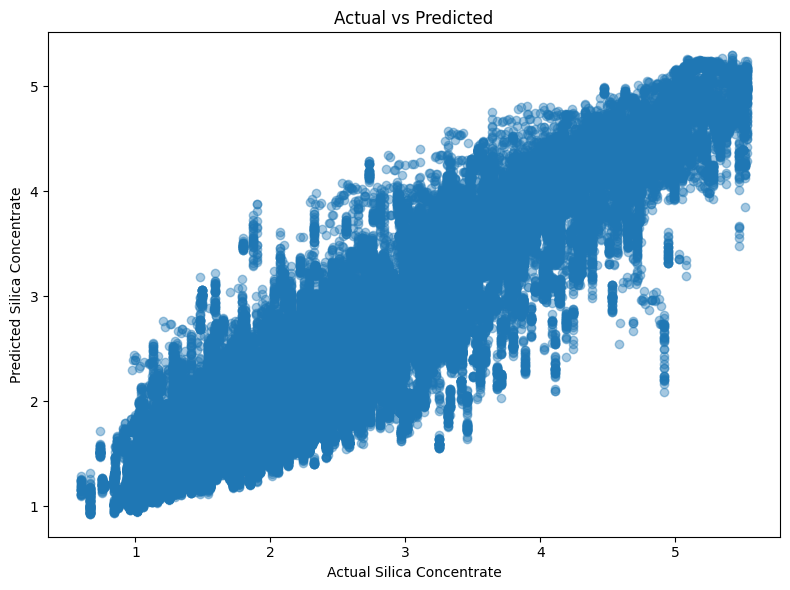

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Silica Concentrate")
plt.ylabel("Predicted Silica Concentrate")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.savefig("graphs/actual_vs_predicted.png", dpi=300)
plt.show()

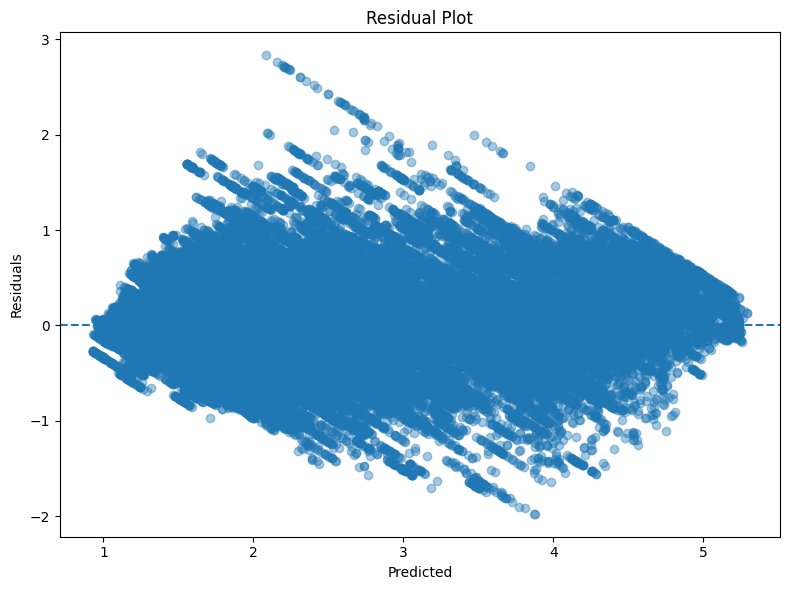

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.4)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.savefig("graphs/residual_plot.png", dpi=300)
plt.show()

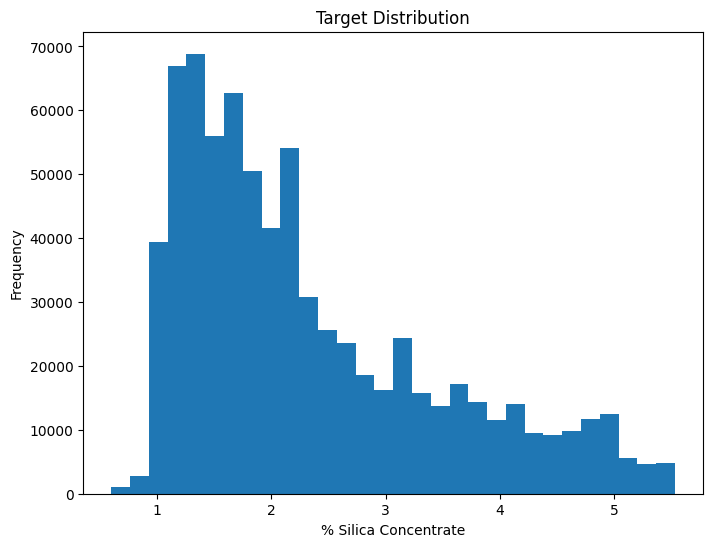

In [24]:
plt.figure(figsize=(8,6))
plt.hist(y, bins=30)
plt.xlabel("% Silica Concentrate")
plt.ylabel("Frequency")
plt.title("Target Distribution")

plt.savefig("graphs/target_distribution.png", dpi=300)
plt.show()

In [25]:
import joblib

joblib.dump(model, "mining_quality_prediction_model.pkl")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [26]:
print("="*50)
print("QUALITY PREDICTION IN A MINING PROCESS")
print("="*50)

print(f"Dataset Shape : {df.shape}")
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples : {X_test.shape[0]}")

print("\nModel Performance")
print("-------------------------")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score : {r2:.4f}")

print("\n✅ Project Completed Successfully!")

QUALITY PREDICTION IN A MINING PROCESS
Dataset Shape : (737453, 24)
Training Samples : 589962
Testing Samples : 147491

Model Performance
-------------------------
MAE : 0.2799
MSE : 0.1450
RMSE: 0.3807
R2 Score : 0.8853

✅ Project Completed Successfully!
